# Thyroid Disease Prediction — Model 1: Random Forest (Baseline)

Loads `data/processed/train.csv` and `data/processed/test.csv` (produced by
`00_prepare_data.ipynb`). The `class` column is already numeric (`1`/`2`/`3`)
straight from the raw data, so no label encoding is needed — we train
directly on it and only use `class_labels.json` to make plots/reports
readable.

Random Forest doesn't need feature scaling either, so this notebook does no
preprocessing at all beyond separating features from the target.

This notebook trains and evaluates a **default (untuned) Random Forest** as
the baseline classical ML model. Hyperparameter tuning is handled separately
in `02_random_forest_tuning.ipynb`, which reloads this baseline for
before/after comparison.


## 0. Setup

In [11]:
import warnings
warnings.filterwarnings("ignore")

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

PROCESSED_DIR = "data/processed"


## 1. Load the prepared data

In [12]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

X_train = train_df.drop(columns=["class"])
X_test = test_df.drop(columns=["class"])
y_train = train_df["class"].values
y_test = test_df["class"].values

with open(os.path.join(PROCESSED_DIR, "class_labels.json")) as f:
    class_labels = {int(k): v for k, v in json.load(f).items()}

# Sorted so index order matches ascending class codes (1, 2, 3) for reports/plots
sorted_classes = sorted(class_labels.keys())
target_names = [class_labels[c] for c in sorted_classes]
feature_names = X_train.columns.tolist()

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", dict(zip(sorted_classes, target_names)))


X_train: (5760, 21)  X_test: (1440, 21)
Classes: {1: 'hyperthyroid', 2: 'hypothyroid', 3: 'normal'}


## 2. Model 1 — Random Forest (baseline, untuned)

Random Forest is a strong, low-effort baseline for tabular clinical data like
this: it handles the mix of continuous + binary features fine without
scaling, is fairly robust to the class imbalance in this dataset (~92%
normal), and gives us feature importances for free — useful when comparing
against the deep learning track later.

We train it here with default hyperparameters (aside from `class_weight`,
needed to handle the imbalance) so we have a clean **before-tuning**
reference point. Tuning happens in the next notebook.


In [13]:
# 2.1 Train baseline Random Forest (default hyperparameters)
best_rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",  # thyroid classes are imbalanced (~92% normal)
    n_jobs=-1,
)

best_rf.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [14]:
# 2.2 Evaluate on the held-out test set
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy:         {acc:.4f}")
print(f"Precision(macro): {prec_macro:.4f}")
print(f"Recall(macro):    {rec_macro:.4f}")
print(f"F1(macro):        {f1_macro:.4f}")
print()
print(classification_report(y_test, y_pred, labels=sorted_classes, target_names=target_names, zero_division=0))


Accuracy:         0.9958
Precision(macro): 0.9691
Recall(macro):    0.9985
F1(macro):        0.9834

              precision    recall  f1-score   support

hyperthyroid       0.97      1.00      0.99        33
 hypothyroid       0.94      1.00      0.97        74
      normal       1.00      1.00      1.00      1333

    accuracy                           1.00      1440
   macro avg       0.97      1.00      0.98      1440
weighted avg       1.00      1.00      1.00      1440



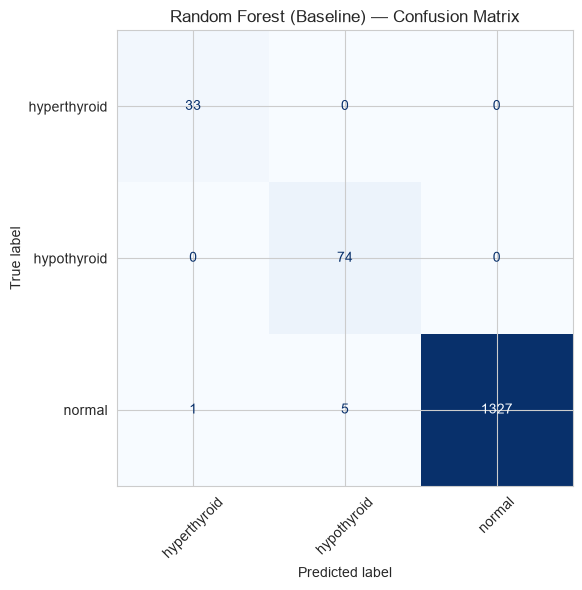

In [15]:
# 2.3 Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, labels=sorted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Random Forest (Baseline) — Confusion Matrix")
plt.tight_layout()
plt.show()


In [16]:
# 2.4 ROC-AUC (multiclass, one-vs-rest)
try:
    auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro, OvR): {auc_ovr:.4f}")
except ValueError as e:
    print("Could not compute multiclass ROC-AUC:", e)


ROC-AUC (macro, OvR): 1.0000


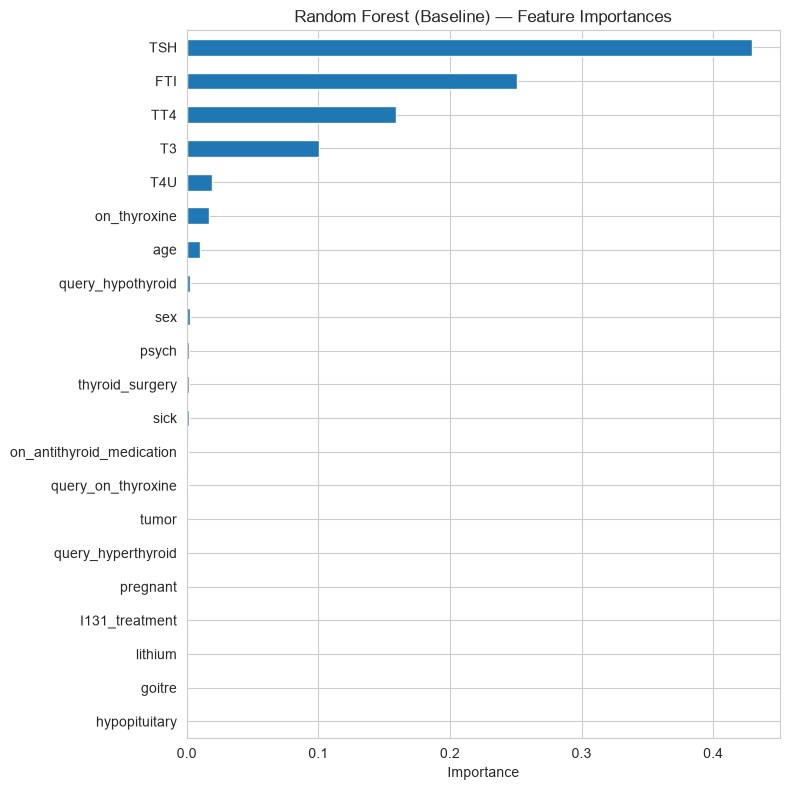

TSH                          0.429310
FTI                          0.251037
TT4                          0.159323
T3                           0.100704
T4U                          0.019206
on_thyroxine                 0.017303
age                          0.009913
query_hypothyroid            0.002309
sex                          0.002269
psych                        0.002047
thyroid_surgery              0.001552
sick                         0.001404
on_antithyroid_medication    0.000620
query_on_thyroxine           0.000613
tumor                        0.000588
query_hyperthyroid           0.000532
pregnant                     0.000389
I131_treatment               0.000368
lithium                      0.000308
goitre                       0.000205
hypopituitary                0.000000
dtype: float64

In [17]:
# 2.5 Feature importance
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
feat_imp.sort_values().plot(kind="barh")
plt.title("Random Forest (Baseline) — Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feat_imp


## 3. Save the baseline model and results

These are reloaded in `02_random_forest_tuning.ipynb` for the before/after comparison.


In [18]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

joblib.dump(best_rf, "models/random_forest_baseline.joblib")

results_summary = pd.DataFrame([{
    "model": "Random Forest (baseline)",
    "accuracy": acc,
    "precision_macro": prec_macro,
    "recall_macro": rec_macro,
    "f1_macro": f1_macro,
}])
results_summary.to_csv("results/random_forest_baseline_results.csv", index=False)
results_summary


,model,accuracy,precision_macro,recall_macro,f1_macro
0,Random Forest (baseline),0.995833,0.969099,0.9985,0.98338
